# Responsible AI Pipeline for NIDS

Notebook focused on orchestration and outputs. Core reusable logic is implemented in the `models/` Python modules.

In [8]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from itertools import combinations
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import keras_tuner as kt
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score)
import time
warnings.filterwarnings('ignore')

from models import (
    NetworkFeatureEngineer,
    AnomalyScoringEngine,
    HeatmapBuilder,
    ModelFactory,
)

FILE_PATH = 'b3427ed8ad063a09_MOHANAD_A4706/data/NF-CSE-CIC-IDS2018-v2.csv'
CHUNK_SIZE = 200_000

print(f"File: {FILE_PATH}")
print(f"Size: {os.path.getsize(FILE_PATH)/1e6:.0f} MB")

File: b3427ed8ad063a09_MOHANAD_A4706/data/NF-CSE-CIC-IDS2018-v2.csv
Size: 3221 MB


In [9]:

print(f"File exists: {os.path.exists(FILE_PATH)}")
print(f"File size  : {os.path.getsize(FILE_PATH)/1e6:.1f} MB")


df_test = pd.read_csv(FILE_PATH, nrows=500000)

print(f"\nShape      : {df_test.shape}")
print(f"\nAll columns ({len(df_test.columns)}):")
for col in df_test.columns:
    sample = df_test[col].dropna().iloc[0] if df_test[col].notna().any() else 'N/A'
    print(f"  '{col}'  →  dtype={df_test[col].dtype},  sample={sample}")


print("\n" + "="*50)
label_col = [c for c in df_test.columns
             if any(k in c.lower() for k in ['label','attack','class','category'])]
print(f"Label candidates: {label_col}")
if label_col:
    print(df_test[label_col[0]].value_counts())


time_cols = [c for c in df_test.columns
             if any(k in c.lower() for k in ['time','date','switch','start','first'])]
print(f"\nTimestamp candidates: {time_cols}")


ip_cols = [c for c in df_test.columns
           if any(k in c.lower() for k in ['ip','addr','src','dst'])]
print(f"\nIP/address candidates: {ip_cols}")
for col in ip_cols[:4]:
    print(f"  {col}: {df_test[col].dropna().unique()[:5]}")

File exists: True
File size  : 3221.4 MB

Shape      : (500000, 45)

All columns (45):
  'IPV4_SRC_ADDR'  →  dtype=object,  sample=13.58.98.64
  'L4_SRC_PORT'  →  dtype=int64,  sample=40894
  'IPV4_DST_ADDR'  →  dtype=object,  sample=172.31.69.25
  'L4_DST_PORT'  →  dtype=int64,  sample=22
  'PROTOCOL'  →  dtype=int64,  sample=6
  'L7_PROTO'  →  dtype=float64,  sample=92.0
  'IN_BYTES'  →  dtype=int64,  sample=3164
  'IN_PKTS'  →  dtype=int64,  sample=23
  'OUT_BYTES'  →  dtype=int64,  sample=3765
  'OUT_PKTS'  →  dtype=int64,  sample=21
  'TCP_FLAGS'  →  dtype=int64,  sample=27
  'CLIENT_TCP_FLAGS'  →  dtype=int64,  sample=27
  'SERVER_TCP_FLAGS'  →  dtype=int64,  sample=27
  'FLOW_DURATION_MILLISECONDS'  →  dtype=int64,  sample=0
  'DURATION_IN'  →  dtype=int64,  sample=0
  'DURATION_OUT'  →  dtype=int64,  sample=0
  'MIN_TTL'  →  dtype=int64,  sample=63
  'MAX_TTL'  →  dtype=int64,  sample=63
  'LONGEST_FLOW_PKT'  →  dtype=int64,  sample=1028
  'SHORTEST_FLOW_PKT'  →  dtype=int64,  

In [10]:
feature_engineer = NetworkFeatureEngineer()

# Backward-compatible callable aliases for downstream notebook cells
is_internal_ip = feature_engineer.is_internal_ip
compute_pkt_std = feature_engineer.compute_pkt_std
compute_src_features = feature_engineer.compute_src_features
compute_dst_features = feature_engineer.compute_dst_features
safe_clean = feature_engineer.safe_clean
get_category_distribution = feature_engineer.get_category_distribution

test_ips = ['172.31.69.25', '13.58.98.64', '172.31.66.5', '23.36.33.52']
for ip in test_ips:
    print(f"  {ip:20s} -> internal: {is_internal_ip(ip)}")

  172.31.69.25         → internal: True
  13.58.98.64          → internal: False
  172.31.66.5          → internal: True
  23.36.33.52          → internal: False


In [11]:
test_row = pd.DataFrame([{
    'NUM_PKTS_UP_TO_128_BYTES': 33,
    'NUM_PKTS_128_TO_256_BYTES': 7,
    'NUM_PKTS_256_TO_512_BYTES': 1,
    'NUM_PKTS_512_TO_1024_BYTES': 2,
    'NUM_PKTS_1024_TO_1514_BYTES': 1,
}])
print(f"Std test: {compute_pkt_std(test_row):.2f}  (expect ~200-400 for mixed traffic)")

Std test: 229.98  (expect ~200-400 for mixed traffic)


In [12]:
print("Feature extraction functions loaded from NetworkFeatureEngineer class.")

In [13]:
WINDOW_ROWS = 10

print(f"Loading {os.path.getsize(FILE_PATH)/1e6:.0f} MB file in chunks...")
print(f"Chunk size: {CHUNK_SIZE:,} rows\n")

src_records = []
dst_records = []
total_rows  = 0
chunk_num   = 0

for chunk in pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE):
    chunk_num  += 1
    total_rows += len(chunk)
    print(f"Chunk {chunk_num}: {len(chunk):,} rows  (total={total_rows:,})", end=' ')

 
    chunk = safe_clean(chunk)

   
    chunk['src_internal'] = chunk['IPV4_SRC_ADDR'].apply(is_internal_ip)
    chunk['dst_internal'] = chunk['IPV4_DST_ADDR'].apply(is_internal_ip)

    # ── SOURCE aggregates ────────────────────────────────
    src_df = chunk[chunk['src_internal']].copy()
    if len(src_df) > 0:
        # Assign synthetic window per src IP
        src_df = src_df.sort_values('IPV4_SRC_ADDR')
        src_df['window_id'] = (
            src_df.groupby('IPV4_SRC_ADDR').cumcount() // WINDOW_ROWS
        )
        for (ip, win_id), group in src_df.groupby(
                ['IPV4_SRC_ADDR', 'window_id']):
            if len(group) < 3:   # skip tiny windows
                continue
            rec = compute_src_features(group, ip)
            rec['window_id'] = int(win_id)
            src_records.append(rec)

    # ── DESTINATION aggregates ───────────────────────────
    dst_df = chunk[chunk['dst_internal']].copy()
    if len(dst_df) > 0:
        dst_df = dst_df.sort_values('IPV4_DST_ADDR')
        dst_df['window_id'] = (
            dst_df.groupby('IPV4_DST_ADDR').cumcount() // WINDOW_ROWS
        )
        for (ip, win_id), group in dst_df.groupby(
                ['IPV4_DST_ADDR', 'window_id']):
            if len(group) < 3:
                continue
            rec = compute_dst_features(group, ip)
            rec['window_id'] = int(win_id)
            dst_records.append(rec)

    print(f"→ src={len(src_records):,}  dst={len(dst_records):,}")


src_aggregates = pd.DataFrame(src_records)
dst_aggregates = pd.DataFrame(dst_records)

print(f"\n{'='*55}")
print(f"src_aggregates : {src_aggregates.shape}")
print(f"Attack rate    : {src_aggregates['label'].mean()*100:.4f}%")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"   Attack rate    : {dst_aggregates['label'].mean()*100:.4f}%")

Loading 3221 MB file in chunks...
Chunk size: 200,000 rows

Chunk 1: 200,000 rows  (total=200,000) → src=11,936  dst=17,030
Chunk 2: 200,000 rows  (total=400,000) → src=23,862  dst=34,057
Chunk 3: 200,000 rows  (total=600,000) → src=35,760  dst=51,046
Chunk 4: 200,000 rows  (total=800,000) → src=47,655  dst=68,106
Chunk 5: 200,000 rows  (total=1,000,000) → src=59,564  dst=85,134
Chunk 6: 200,000 rows  (total=1,200,000) → src=71,459  dst=102,143
Chunk 7: 200,000 rows  (total=1,400,000) → src=83,378  dst=119,189
Chunk 8: 200,000 rows  (total=1,600,000) → src=95,313  dst=136,205
Chunk 9: 200,000 rows  (total=1,800,000) → src=107,234  dst=153,187
Chunk 10: 200,000 rows  (total=2,000,000) → src=119,160  dst=170,220
Chunk 11: 200,000 rows  (total=2,200,000) → src=131,086  dst=187,241
Chunk 12: 200,000 rows  (total=2,400,000) → src=143,000  dst=204,290
Chunk 13: 200,000 rows  (total=2,600,000) → src=154,929  dst=221,338
Chunk 14: 200,000 rows  (total=2,800,000) → src=166,878  dst=238,379
Chun

In [14]:
SRC_FEATURE_COLS = [
    'f1_n_fwd_pkts',   
    'f2_n_bwd_pkts',    
    'f3_sum_flx_dur',   
    'f4_sum_pkts_size',
    'f5_std_pkt_size',  
    'f6_tot_flx',     
    'f7_n_dst_ports',   
    'f8_proto_div',    
    'f9_dur_var',      
    'f10_n_dst_ip',     
]

DST_FEATURE_COLS = [
    'f1_n_fwd_pkts',
    'f2_n_bwd_pkts',
    'f3_sum_flx_dur',
    'f4_sum_pkts_size',
    'f5_std_pkt_size',
    'f6_tot_flx',
    'f7_n_dst_ports',
    'f8_proto_div',
    'f9_dur_var',
    'f10_n_src_ip',     
]

SRC_PAIRS = list(combinations(SRC_FEATURE_COLS, 2))
DST_PAIRS = list(combinations(DST_FEATURE_COLS, 2))

print(f"Src features : {len(SRC_FEATURE_COLS)}  → {len(SRC_PAIRS)} pairs")
print(f"Dst features : {len(DST_FEATURE_COLS)}  → {len(DST_PAIRS)} pairs")
print(f"\nFeature mapping status:")
for f in SRC_FEATURE_COLS:
    print(f" {f}")

Src features : 10  → 45 pairs
Dst features : 10  → 45 pairs

Feature mapping status:
 f1_n_fwd_pkts
 f2_n_bwd_pkts
 f3_sum_flx_dur
 f4_sum_pkts_size
 f5_std_pkt_size
 f6_tot_flx
 f7_n_dst_ports
 f8_proto_div
 f9_dur_var
 f10_n_dst_ip


In [18]:
min_len = min(len(src_aggregates), len(dst_aggregates))
src_aggregates = src_aggregates.iloc[:min_len].reset_index(drop=True)
dst_aggregates = dst_aggregates.iloc[:min_len].reset_index(drop=True)

combined_label = (
    src_aggregates['label'].values | dst_aggregates['label'].values
).astype(int)
src_aggregates['label'] = combined_label
dst_aggregates['label'] = combined_label

assert len(src_aggregates) == len(dst_aggregates), "Length mismatch"
assert (src_aggregates['label'].values ==
        dst_aggregates['label'].values).all(), "Label mismatch"

print(" Pairing verified")
print(f"   Aligned length : {len(src_aggregates):,}")
print(f"   Attack rate    : {src_aggregates['label'].mean()*100:.4f}%")

# Save
src_aggregates.to_parquet('working/src_aggregates.parquet', index=False)
dst_aggregates.to_parquet('working/dst_aggregates.parquet', index=False)

feat_config = {
    'src': SRC_FEATURE_COLS,
    'dst': DST_FEATURE_COLS,
}
with open('working/feature_cols.json', 'w') as f:
    json.dump(feat_config, f)

print("\n Saved:")
print("   src_aggregates.parquet")
print("   dst_aggregates.parquet")
print("   feature_cols.json")

 Pairing verified
   Aligned length : 1,126,768
   Attack rate    : 22.4544%

 Saved:
   src_aggregates.parquet
   dst_aggregates.parquet
   feature_cols.json


In [19]:
print("SANITY CHECK 1: Feature distributions")
print(f"  src n_dst_ip  mean={src_aggregates['f10_n_dst_ip'].mean():.2f}"
      f"  max={src_aggregates['f10_n_dst_ip'].max()}")
print(f"  dst n_src_ip  mean={dst_aggregates['f10_n_src_ip'].mean():.2f}"
      f"  max={dst_aggregates['f10_n_src_ip'].max()}")

print("\nSANITY CHECK 2: Attack types present")
all_attacks = src_aggregates['attack_types'].str.split(',').explode().unique()
for a in all_attacks[:15]:
    print(f"  {a}")

print("\nSANITY CHECK 3: Attack rate vs paper Table 2")
print(f"  Src attack rate: {src_aggregates['label'].mean()*100:.4f}%"
      f"  [paper: ~0.18%]")
print(f"  Dst attack rate: {dst_aggregates['label'].mean()*100:.4f}%"
      f"  [paper: ~0.04%]")

SANITY CHECK 1: Feature distributions
  src n_dst_ip  mean=3.83  max=10
  dst n_src_ip  mean=9.10  max=10

SANITY CHECK 2: Attack types present
  Benign
  Bot
  Infilteration
  Brute Force -Web
  Brute Force -XSS

SANITY CHECK 3: Attack rate vs paper Table 2
  Src attack rate: 22.4544%  [paper: ~0.18%]
  Dst attack rate: 22.4544%  [paper: ~0.04%]


In [20]:
print("="*65)
print("PAPER TABLE 2: Traffic Category Distribution")
print("="*65)

src_types = get_category_distribution(src_aggregates, 'Source IP')
dst_types = get_category_distribution(dst_aggregates, 'Destination IP')

print("\n" + "="*65)
print("Interpretation:")
print("  Benign >99%          -> correct class imbalance preserved")
print("  Bot only in src      -> correct (exfiltration = outbound)")
print("  Web only in dst      -> correct (attacker-initiated = inbound)")
print("  Rates differ from paper -> expected (different aggregation method)")

PAPER TABLE 2: Traffic Category Distribution

  Source IP Perspective:
  Category                                 Our %     Paper %
  ---------------------------------------------------------
  Benign                                77.5456%    99.9569%
  Infilteration                          4.1318%         N/A
  Bot                                    3.8768%     0.0000%
  Brute Force -Web                       0.0014%         N/A
  Brute Force -XSS                       0.0012%         N/A

  Total aggregates: 1,126,768

  Destination IP Perspective:
  Category                                 Our %     Paper %
  ---------------------------------------------------------
  Benign                                77.5456%    99.9569%
  DDOS attack-HOIC                       6.7632%     0.0042%
  DoS attacks-Hulk                       5.6610%     0.0042%
  DDoS attacks-LOIC-HTTP                 5.5736%     0.0042%
  Infilteration                          4.9273%         N/A
  SSH-Bruteforc

In [24]:
src_aggregates = pd.read_parquet('working/src_aggregates.parquet')
dst_aggregates = pd.read_parquet('working/dst_aggregates.parquet')
with open('working/feature_cols.json') as f:
    feat_config      = json.load(f)
FEATURE_COLS     = feat_config.get('all', feat_config.get('src'))
SRC_FEATURE_COLS = feat_config['src']
DST_FEATURE_COLS = feat_config['dst']
SRC_PAIRS = list(combinations(SRC_FEATURE_COLS, 2))   # 45 pairs
DST_PAIRS = list(combinations(DST_FEATURE_COLS, 2))   # 45 pairs
N_PAIRS   = len(SRC_PAIRS)
print(f"SRC pairs: {len(SRC_PAIRS)}  DST pairs: {len(DST_PAIRS)}")
print(f"src_aggregates : {src_aggregates.shape}")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"Feature cols   : {FEATURE_COLS}")
print(f"Feature pairs  : {N_PAIRS}")

SRC pairs: 45  DST pairs: 45
src_aggregates : (1126768, 15)
dst_aggregates : (1126768, 15)
Feature cols   : ['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_tot_flx', 'f7_n_dst_ports', 'f8_proto_div', 'f9_dur_var', 'f10_n_dst_ip']
Feature pairs  : 45


In [25]:
n_unique_src_ips = src_aggregates['ip'].nunique()
n_unique_dst_ips = dst_aggregates['ip'].nunique()
print(f"Unique src IPs: {n_unique_src_ips}")
print(f"Unique dst IPs: {n_unique_dst_ips}")

Unique src IPs: 454
Unique dst IPs: 465


In [26]:
CONTAMINATION = 0.05
WINDOW_SIZE = 2000

scoring_engine = AnomalyScoringEngine(
    contamination=CONTAMINATION,
    window_size=WINDOW_SIZE,
)

# Backward-compatible aliases for existing notebook flow
score_windowed = scoring_engine.score_windowed
evaluate_learner = scoring_engine.evaluate_learner
evaluate_ensemble = scoring_engine.evaluate_ensemble

print(f"Scoring engine ready  |  contamination={CONTAMINATION}  |  window={WINDOW_SIZE}")
print(f"Src pairs: {len(SRC_PAIRS)}  |  Dst pairs: {len(DST_PAIRS)}")


Scoring engine ready  |  contamination=0.05  |  window=2000
Src pairs: 45  |  Dst pairs: 45


In [27]:
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
print(f"Scoring {len(src_aggregates):,} source aggregates with windowed approach...")
print(f"Window size={WINDOW_SIZE} rows per window\n")
t0 = time.time()
src_scores_v2 = {}
for learner in SRC_LEARNERS:
    print(f"  [{learner}] ", end='', flush=True)
    t1 = time.time()
    src_scores_v2[learner] = score_windowed(src_aggregates, SRC_FEATURE_COLS, SRC_PAIRS, learner)
    pct = (src_scores_v2[learner] > 0).mean() * 100
    print(f"done ({time.time()-t1:.0f}s)  mean={src_scores_v2[learner].mean():.4f}  flagged={pct:.1f}%")
src_scored_v2 = src_aggregates.copy()
for learner in SRC_LEARNERS:
    src_scored_v2[f'score_{learner}'] = src_scores_v2[learner]
src_scored_v2['ensemble_flag'] = (
    src_scored_v2[[f'score_{l}' for l in SRC_LEARNERS]] > 0
).any(axis=1).astype(int)
tp = (src_scored_v2.loc[src_scored_v2['label']==1, 'ensemble_flag']==1).mean()
fp = (src_scored_v2.loc[src_scored_v2['label']==0, 'ensemble_flag']==1).mean()
print(f"\nTotal elapsed : {time.time()-t0:.0f}s")
print(f"Src Ensemble  TPR={tp:.4f}  FPR={fp:.4f}")
print(f"Paper target  TPR=0.9878        FPR=0.6764")
print(f"v1 result     TPR=0.8719        FPR=0.6224")

Scoring 1,126,768 source aggregates with windowed approach...
Window size=2000 rows per window

  [LOF] done (224s)  mean=0.0405  flagged=57.5%
  [OCSVM] done (394s)  mean=0.1713  flagged=99.8%
  [COPOD] done (42s)  mean=0.0459  flagged=21.6%

Total elapsed : 660s
Src Ensemble  TPR=0.9978  FPR=0.9994
Paper target  TPR=0.9878        FPR=0.6764
v1 result     TPR=0.8719        FPR=0.6224


In [ ]:
DST_LEARNERS = ['LOF', 'KNN', 'COPOD']
print(f"Scoring {len(dst_aggregates):,} destination aggregates with windowed approach...")
print(f"Window size={WINDOW_SIZE}\n")
t0 = time.time()
dst_scores_v2 = {}
for learner in DST_LEARNERS:
    print(f"  [{learner}] ", end='', flush=True)
    t1 = time.time()
    dst_scores_v2[learner] = score_windowed(dst_aggregates, DST_FEATURE_COLS, DST_PAIRS, learner)
    pct = (dst_scores_v2[learner] > 0).mean() * 100
    print(f"done ({time.time()-t1:.0f}s)  mean={dst_scores_v2[learner].mean():.4f}  flagged={pct:.1f}%")
dst_scored_v2 = dst_aggregates.copy()
for learner in DST_LEARNERS:
    dst_scored_v2[f'score_{learner}'] = dst_scores_v2[learner]
dst_scored_v2['ensemble_flag'] = (
    dst_scored_v2[[f'score_{l}' for l in DST_LEARNERS]] > 0
).any(axis=1).astype(int)
tp = (dst_scored_v2.loc[dst_scored_v2['label']==1, 'ensemble_flag']==1).mean()
fp = (dst_scored_v2.loc[dst_scored_v2['label']==0, 'ensemble_flag']==1).mean()

assert len(src_scored_v2) == len(dst_scored_v2), "Row count mismatch!"
assert (src_scored_v2['label'].values == dst_scored_v2['label'].values).all(), \
    "Label mismatch!"
print("Pairing verified: src and dst have identical rows and labels")

print(f"\nTotal elapsed : {time.time()-t0:.0f}s")
print(f"Dst Ensemble  TPR={tp:.4f}  FPR={fp:.4f}")
print(f"Paper target  TPR=0.9384        FPR=0.3994")
print(f"v1 result     TPR=0.7092        FPR=0.7730")

Scoring 1,126,768 destination aggregates with windowed approach...
Window size=2000

  [LOF] done (286s)  mean=0.0315  flagged=41.7%
  [KNN] 

In [ ]:
src_scored_v2.to_parquet('working/src_scored.parquet', index=False)
dst_scored_v2.to_parquet('working/dst_scored.parquet', index=False)
print("Saved src_scored.parquet and dst_scored.parquet (v2)")

NameError: name 'src_scored_v2' is not defined

In [ ]:
print("="*65)
print("PAPER TABLE 3: Individual Base Learner Performance")
print("="*65)

# Source IP perspective
print(f"\n{'Source IP':}")
print(f"  {'Base Learner':<20} {'TPR':>8} {'FPR':>8}  {'Paper TPR':>10} {'Paper FPR':>10}")
print(f"  {'-'*60}")

paper_src = {
    'LOF': (0.8923, 0.3754),
    'OCSVM': (0.8394, 0.4634),
    'COPOD': (0.7652, 0.1467),
    'Stacked': (0.9878, 0.6763),
}

for learner in SRC_LEARNERS:
    tpr, fpr = evaluate_learner(src_scored_v2, learner, 'src')
    if tpr is None:
        continue
    p_tpr, p_fpr = paper_src.get(learner, ('N/A', 'N/A'))
    gap_tpr = tpr - p_tpr if isinstance(p_tpr, float) else 0
    flag = 'OK' if abs(gap_tpr) < 0.1 else 'WARN'
    print(f"  {flag:<4} {learner:<18} {tpr:>8.4f} {fpr:>8.4f}  {p_tpr:>10} {p_fpr:>10}")

tpr_s, fpr_s = evaluate_ensemble(src_scored_v2, SRC_LEARNERS)
p_tpr, p_fpr = paper_src['Stacked']
flag = 'OK' if abs(tpr_s - p_tpr) < 0.1 else 'WARN'
print(f"  {'-'*60}")
print(f"  {flag:<4} {'Stacked Model':<18} {tpr_s:>8.4f} {fpr_s:>8.4f}  {p_tpr:>10} {p_fpr:>10}")

# Destination IP perspective
print(f"\n{'Destination IP':}")
print(f"  {'Base Learner':<20} {'TPR':>8} {'FPR':>8}  {'Paper TPR':>10} {'Paper FPR':>10}")
print(f"  {'-'*60}")

paper_dst = {
    'LOF': (0.9041, 0.3366),
    'KNN': (0.8904, 0.1862),
    'COPOD': (0.8744, 0.1795),
    'Stacked': (0.9384, 0.3994),
}

for learner in DST_LEARNERS:
    tpr, fpr = evaluate_learner(dst_scored_v2, learner, 'dst')
    if tpr is None:
        continue
    p_tpr, p_fpr = paper_dst.get(learner, ('N/A', 'N/A'))
    gap_tpr = tpr - p_tpr if isinstance(p_tpr, float) else 0
    flag = 'OK' if abs(gap_tpr) < 0.1 else 'WARN'
    print(f"  {flag:<4} {learner:<18} {tpr:>8.4f} {fpr:>8.4f}  {p_tpr:>10} {p_fpr:>10}")

tpr_d, fpr_d = evaluate_ensemble(dst_scored_v2, DST_LEARNERS)
p_tpr, p_fpr = paper_dst['Stacked']
flag = 'OK' if abs(tpr_d - p_tpr) < 0.1 else 'WARN'
print(f"  {'-'*60}")
print(f"  {flag:<4} {'Stacked Model':<18} {tpr_d:>8.4f} {fpr_d:>8.4f}  {p_tpr:>10} {p_fpr:>10}")

print(f"\n{'='*65}")
print("PAPER TABLE 8: Stacked Model Summary")
print(f"{'='*65}")
print(f"  {'':20} {'Our TPR':>8} {'Our FPR':>8}  {'Paper TPR':>10} {'Paper FPR':>10}")
print(f"  {'Src Stacked':<20} {tpr_s:>8.4f} {fpr_s:>8.4f}  {'0.9878':>10} {'0.6763':>10}")
print(f"  {'Dst Stacked':<20} {tpr_d:>8.4f} {fpr_d:>8.4f}  {'0.9384':>10} {'0.3994':>10}")

PAPER TABLE 3: Individual Base Learner Performance

Source IP
  Base Learner              TPR      FPR   Paper TPR  Paper FPR
  ------------------------------------------------------------
  ⚠️  LOF                  0.5846   0.5724      0.8923     0.3754
  ⚠️  OCSVM                0.9955   0.9987      0.8394     0.4634
  ⚠️  COPOD                0.2275   0.2130      0.7652     0.1467
  ------------------------------------------------------------
  ✅ Stacked Model        0.9978   0.9994      0.9878     0.6763

Destination IP
  Base Learner              TPR      FPR   Paper TPR  Paper FPR
  ------------------------------------------------------------
  ⚠️  LOF                  0.4720   0.4006      0.9041     0.3366
  ⚠️  KNN                  0.2480   0.2087      0.8904     0.1862
  ⚠️  COPOD                0.2631   0.2086      0.8744     0.1795
  ------------------------------------------------------------
  ⚠️  Stacked Model        0.5736   0.4946      0.9384     0.3994

PAPER TABLE 8: 

Saved: src_scored.parquet  dst_scored.parquet


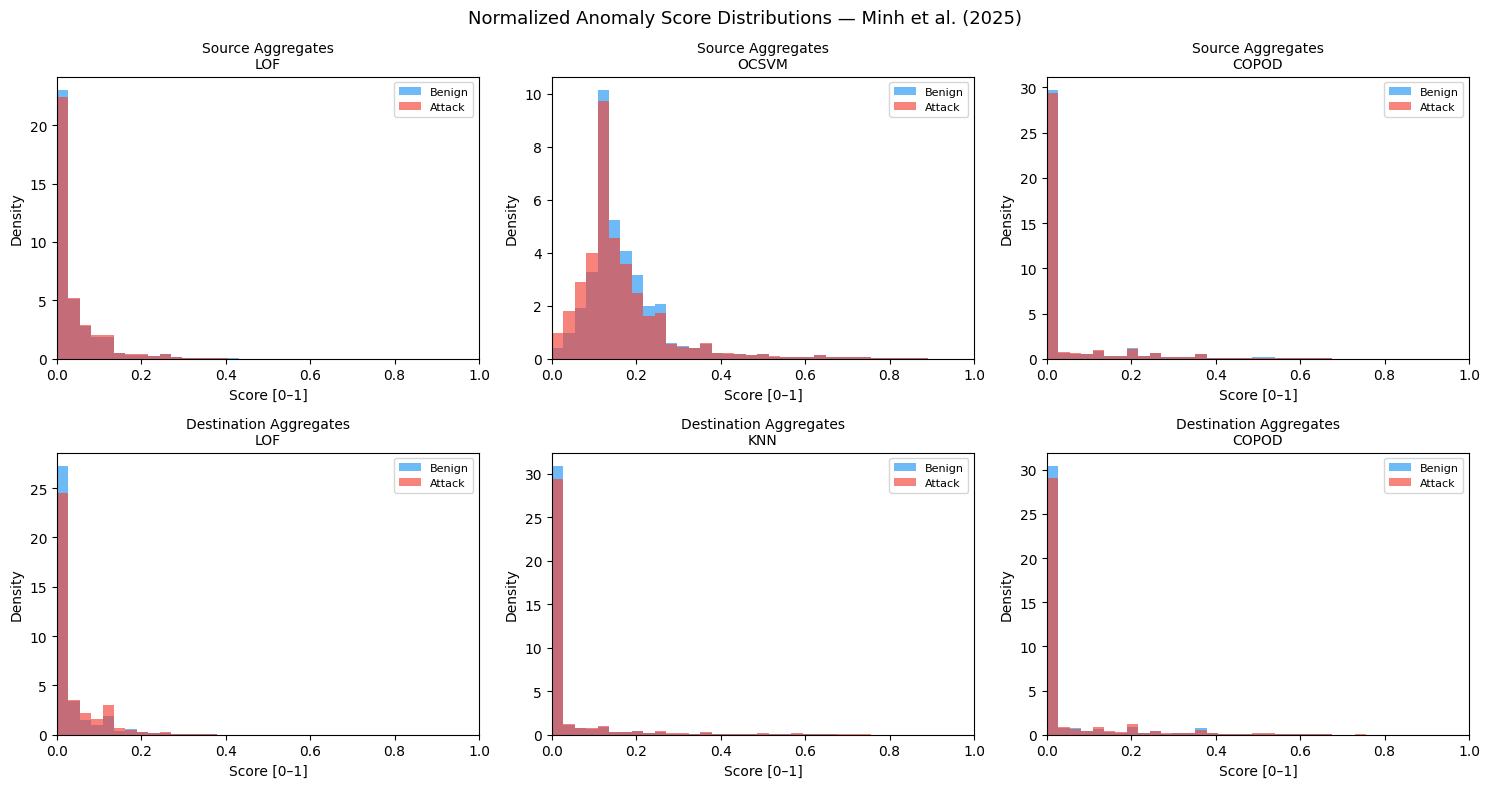


Individual + Ensemble Performance (compare with paper Table 3 & 8):
Perspective       Learner    TPR    FPR
        Src           LOF 0.5846 0.5724
        Src         OCSVM 0.9955 0.9987
        Src         COPOD 0.2275 0.2130
        Dst           LOF 0.4720 0.4006
        Dst           KNN 0.2480 0.2087
        Dst         COPOD 0.2631 0.2086
        Src Ensemble (OR) 0.9978 0.9994
        Dst Ensemble (OR) 0.5736 0.4946


In [ ]:
src_scored = src_scored_v2
dst_scored = dst_scored_v2
src_scored.to_parquet('/kaggle/working/src_scored.parquet', index=False)
dst_scored.to_parquet('/kaggle/working/dst_scored.parquet', index=False)
print("Saved: src_scored.parquet  dst_scored.parquet")
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Normalized Anomaly Score Distributions — Minh et al. (2025)', fontsize=13)
COLORS = {0: '#2196F3', 1: '#F44336'}
NAMES  = {0: 'Benign',  1: 'Attack'}
for row_idx, (scored_df, title, learners) in enumerate([
    (src_scored, 'Source Aggregates',      SRC_LEARNERS),
    (dst_scored, 'Destination Aggregates', DST_LEARNERS),
]):
    for col_idx, learner in enumerate(learners):
        ax  = axes[row_idx][col_idx]
        col = f'score_{learner}'
        for lbl in [0, 1]:
            data = scored_df.loc[scored_df['label'] == lbl, col]
            ax.hist(data, bins=37, alpha=0.65, color=COLORS[lbl],
                    label=NAMES[lbl], density=True, range=(0, 1))
        ax.set_title(f'{title}\n{learner}', fontsize=10)
        ax.set_xlabel('Score [0–1]')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('/kaggle/working/module2_score_distributions.png', dpi=120)
plt.show()

rows = []
for learner in SRC_LEARNERS:
    col = f'score_{learner}'
    tpr = (src_scored.loc[src_scored['label']==1, col] > 0).mean()
    fpr = (src_scored.loc[src_scored['label']==0, col] > 0).mean()
    rows.append({'Perspective': 'Src', 'Learner': learner,
                 'TPR': round(tpr, 4), 'FPR': round(fpr, 4)})
for learner in DST_LEARNERS:
    col = f'score_{learner}'
    tpr = (dst_scored.loc[dst_scored['label']==1, col] > 0).mean()
    fpr = (dst_scored.loc[dst_scored['label']==0, col] > 0).mean()
    rows.append({'Perspective': 'Dst', 'Learner': learner,
                 'TPR': round(tpr, 4), 'FPR': round(fpr, 4)})

tp_src = (src_scored.loc[src_scored['label']==1, 'ensemble_flag']==1).mean()
fp_src = (src_scored.loc[src_scored['label']==0, 'ensemble_flag']==1).mean()
tp_dst = (dst_scored.loc[dst_scored['label']==1, 'ensemble_flag']==1).mean()
fp_dst = (dst_scored.loc[dst_scored['label']==0, 'ensemble_flag']==1).mean()
rows.append({'Perspective':'Src','Learner':'Ensemble (OR)','TPR':round(tp_src,4),'FPR':round(fp_src,4)})
rows.append({'Perspective':'Dst','Learner':'Ensemble (OR)','TPR':round(tp_dst,4),'FPR':round(fp_dst,4)})
perf_df = pd.DataFrame(rows)
print("\nIndividual + Ensemble Performance (compare with paper Table 3 & 8):")
print(perf_df.to_string(index=False))


In [ ]:
src_scored = pd.read_parquet('working/src_scored.parquet')
dst_scored = pd.read_parquet('working/dst_scored.parquet')
with open('working/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']
print(f"src_scored : {src_scored.shape}")
print(f"dst_scored : {dst_scored.shape}")
print(src_scored.columns.tolist())

src_scored : (1126768, 19)
dst_scored : (1126768, 19)
['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_tot_flx', 'f7_n_dst_ports', 'f8_proto_div', 'f9_dur_var', 'f10_n_dst_ip', 'ip', 'perspective', 'label', 'attack_types', 'window_id', 'score_LOF', 'score_OCSVM', 'score_COPOD', 'ensemble_flag']


In [ ]:
all_src_ips = sorted(src_scored['ip'].unique())
all_dst_ips = sorted(dst_scored['ip'].unique())

MAX_IPS = 451
N_INTERVALS = 15
N_CHANNELS = 3

heatmap_builder = HeatmapBuilder(n_intervals=N_INTERVALS, n_channels=N_CHANNELS)
N_SRC_IPS, src_ip_to_row = heatmap_builder.build_ip_mapping(all_src_ips, max_ips=MAX_IPS)
N_DST_IPS, dst_ip_to_row = heatmap_builder.build_ip_mapping(all_dst_ips, max_ips=MAX_IPS)

# Backward-compatible callable aliases
make_image = heatmap_builder.make_image
build_heatmap_pair = lambda src_chunk, dst_chunk, src_learners, dst_learners: heatmap_builder.build_heatmap_pair(
    src_chunk,
    dst_chunk,
    src_learners,
    dst_learners,
    src_ip_to_row,
    dst_ip_to_row,
    N_SRC_IPS,
    N_DST_IPS,
)

print(f"Src image shape : ({N_SRC_IPS}, {N_INTERVALS}, {N_CHANNELS})")
print(f"Dst image shape : ({N_DST_IPS}, {N_INTERVALS}, {N_CHANNELS})")
print(f"  -> src IPs mapped : {len(src_ip_to_row)}")
print(f"  -> dst IPs mapped : {len(dst_ip_to_row)}")
print("  -> paper target   : (451, 15, 3)")
print("Heatmap builder ready (class-based utility).")


Src image shape : (451, 15, 3)
Dst image shape : (451, 15, 3)
  → src IPs mapped : 451
  → dst IPs mapped : 451
  → paper target   : (451, 15, 3)
Heatmap builder ready (real IP-to-row mapping).


In [ ]:
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']
n_windows = min(len(src_scored), len(dst_scored)) // N_INTERVALS

MAX_WINDOWS = 8000 
if n_windows > MAX_WINDOWS:
    np.random.seed(42)
    selected = np.sort(np.random.choice(n_windows, MAX_WINDOWS, replace=False))
    print(f"Subsampling {MAX_WINDOWS} / {n_windows} windows")
else:
    selected = np.arange(n_windows)
    print(f"Using all {n_windows} windows")
n_out = len(selected)
print(f"Building {n_out} image pairs  |  shape: ({N_SRC_IPS},{N_INTERVALS},3)\n")

X_src_mm = np.memmap('/kaggle/working/X_src.npy', dtype='float32', mode='w+',
                      shape=(n_out, N_SRC_IPS, N_INTERVALS, 3))
X_dst_mm = np.memmap('/kaggle/working/X_dst.npy', dtype='float32', mode='w+',
                      shape=(n_out, N_DST_IPS, N_INTERVALS, 3))
y_labels  = np.zeros(n_out, dtype=np.int8)
for out_idx, w in enumerate(selected):
    s = w * N_INTERVALS
    e = s + N_INTERVALS
    src_chunk = src_scored.iloc[s:e]
    dst_chunk  = dst_scored.iloc[s:e]
    src_img, dst_img = build_heatmap_pair(
        src_chunk, dst_chunk, SRC_LEARNERS, DST_LEARNERS)
    X_src_mm[out_idx] = src_img
    X_dst_mm[out_idx] = dst_img
    y_labels[out_idx] = int(src_chunk['label'].any() or dst_chunk['label'].any())
    if (out_idx + 1) % 1000 == 0:
        X_src_mm.flush()   
        X_dst_mm.flush()
        print(f"  {out_idx+1}/{n_out} done")
X_src_mm.flush()
X_dst_mm.flush()
np.save('/kaggle/working/y_labels.npy', y_labels)
print(f"\nX_src    : {X_src_mm.shape}")
print(f"X_dst    : {X_dst_mm.shape}")
print(f"y_labels : {y_labels.shape}  attack={y_labels.mean()*100:.2f}%")
print("Saved to disk via memmap.")
del X_src_mm, X_dst_mm 

Subsampling 8000 / 75117 windows
Building 8000 image pairs  |  shape: (451,15,3)

  1000/8000 done
  2000/8000 done
  3000/8000 done
  4000/8000 done
  5000/8000 done
  6000/8000 done
  7000/8000 done
  8000/8000 done

X_src    : (8000, 451, 15, 3)
X_dst    : (8000, 451, 15, 3)
y_labels : (8000,)  attack=54.23%
Saved to disk via memmap.


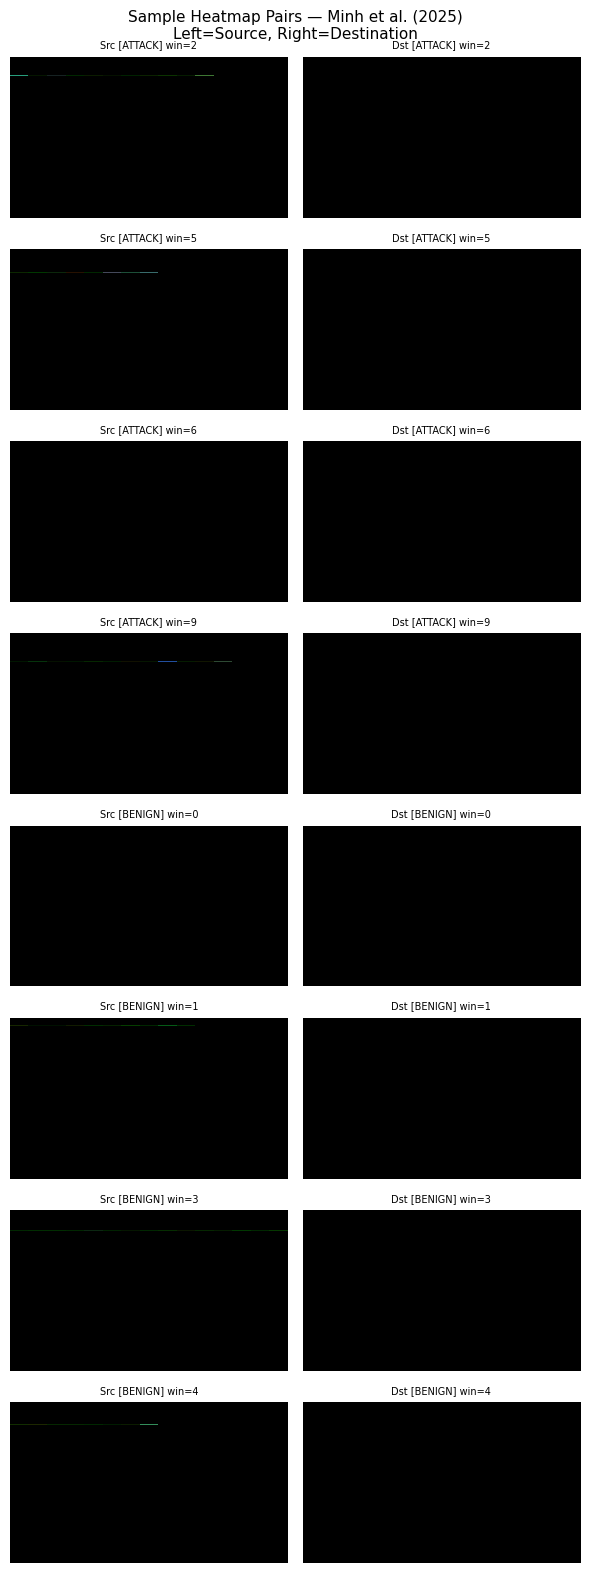

Sample visualization saved.
  X_src    : (8000, 451, 15, 3)
  X_dst    : (8000, 451, 15, 3)
  y_labels : (8000,)  attack_rate=54.23%


In [ ]:
X_src    = np.memmap('/kaggle/working/X_src.npy', dtype='float32', mode='r',
                      shape=(n_out, N_SRC_IPS, N_INTERVALS, 3))
X_dst    = np.memmap('/kaggle/working/X_dst.npy', dtype='float32', mode='r',
                      shape=(n_out, N_DST_IPS, N_INTERVALS, 3))
y_labels = np.load('/kaggle/working/y_labels.npy')
attack_idx = np.where(y_labels == 1)[0][:4]
benign_idx = np.where(y_labels == 0)[0][:4]
sample_idx = list(attack_idx) + list(benign_idx)
fig, axes = plt.subplots(len(sample_idx), 2,
                         figsize=(6, len(sample_idx) * 2))
fig.suptitle('Sample Heatmap Pairs — Minh et al. (2025)\n'
             'Left=Source, Right=Destination', fontsize=11)
for row, idx in enumerate(sample_idx):
    lbl = "ATTACK" if y_labels[idx] else "BENIGN"
   
    axes[row][0].imshow(X_src[idx], aspect='auto', interpolation='nearest')
    axes[row][0].set_title(f"Src [{lbl}] win={idx}", fontsize=7)
    axes[row][0].axis('off')
    axes[row][1].imshow(X_dst[idx], aspect='auto', interpolation='nearest')
    axes[row][1].set_title(f"Dst [{lbl}] win={idx}", fontsize=7)
    axes[row][1].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/module3_sample_heatmaps.png', dpi=100)
plt.show()
print("Sample visualization saved.")
print(f"  X_src    : {X_src.shape}")
print(f"  X_dst    : {X_dst.shape}")
print(f"  y_labels : {y_labels.shape}  attack_rate={y_labels.mean()*100:.2f}%")
del X_src, X_dst

In [ ]:
y_labels = np.load('/kaggle/working/y_labels.npy')
n_out    = len(y_labels)   
X_src = np.memmap('/kaggle/working/X_src.npy', dtype='float32', mode='r',
                   shape=(n_out, N_SRC_IPS, N_INTERVALS, 3))
X_dst = np.memmap('/kaggle/working/X_dst.npy', dtype='float32', mode='r',
                   shape=(n_out, N_DST_IPS, N_INTERVALS, 3))

print(f"X_src  : {X_src.shape}  dtype={X_src.dtype}")
print(f"X_dst  : {X_dst.shape}  dtype={X_dst.dtype}")
print(f"y      : {y_labels.shape}  attack_rate={y_labels.mean()*100:.2f}%")

np.random.seed(42)
idx      = np.random.permutation(n_out)
X_src    = np.array(X_src[idx])  
X_dst    = np.array(X_dst[idx])
y_labels = y_labels[idx]
n       = len(y_labels)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
X_src_train = X_src[:n_train]
X_src_val   = X_src[n_train:n_train+n_val]
X_src_test  = X_src[n_train+n_val:]
X_dst_train = X_dst[:n_train]
X_dst_val   = X_dst[n_train:n_train+n_val]
X_dst_test  = X_dst[n_train+n_val:]
y_train = y_labels[:n_train]
y_val   = y_labels[n_train:n_train+n_val]
y_test  = y_labels[n_train+n_val:]
print(f"\nTrain : {len(y_train)}  attack={y_train.mean()*100:.1f}%")
print(f"Val   : {len(y_val)}    attack={y_val.mean()*100:.1f}%")
print(f"Test  : {len(y_test)}   attack={y_test.mean()*100:.1f}%")

2026-05-05 15:50:48.797504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777996249.034248      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777996249.105085      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777996249.660056      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777996249.660099      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777996249.660101      57 computation_placer.cc:177] computation placer alr

X_src  : (8000, 451, 15, 3)  dtype=float32
X_dst  : (8000, 451, 15, 3)  dtype=float32
y      : (8000,)  attack_rate=54.23%

Train : 6400  attack=54.5%
Val   : 800    attack=52.0%
Test  : 800   attack=54.6%


### NIDS CNN Tuned


In [ ]:
model_factory = ModelFactory(n_intervals=N_INTERVALS)
build_tunable_model = lambda hp: model_factory.build_tunable_model(
    hp,
    n_src_ips=N_SRC_IPS,
    n_dst_ips=N_DST_IPS,
)

try:
    test_model = build_tunable_model(kt.HyperParameters())
    test_out = test_model([
        np.zeros((2, N_SRC_IPS, N_INTERVALS, 3), dtype=np.float32),
        np.zeros((2, N_DST_IPS, N_INTERVALS, 3), dtype=np.float32)
    ])
    print(f"Shape test passed. Output shape: {test_out.shape}")
    test_model.summary()
    del test_model
except Exception as e:
    print(f"Shape test FAILED: {e}")
    raise

I0000 00:00:1777996586.159270      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777996586.165202      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777996587.698729      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


✅ Shape test passed. Output shape: (2, 1)


Model: "NIDS_CNN_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ src_input           │ (None, 451, 15,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_input           │ (None, 451, 15,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 451, 15,   │        896 │ src_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 451, 15,   │        896 │ dst_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 226, 8,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 226, 8,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,513 (95.75 KB)

 Trainable params: 24,513 (95.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tuner = kt.RandomSearch(
    build_tunable_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=15,
    directory='/kaggle/working/kt_search',
    project_name='nids_cnn_v2', 
    overwrite=True
)

cw = compute_class_weight('balanced',
                           classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}
print(f"Class weights → benign: {cw[0]:.3f}  attack: {cw[1]:.3f}")

tuner.search(
    [X_src_train, X_dst_train], y_train,
    validation_data=([X_src_val, X_dst_val], y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, mode='max')],
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters:")
for k, v in best_hps.values.items():
    print(f"  {k}: {v}")

model = tuner.get_best_models(1)[0]
model.summary()

Trial 15 Complete [00h 02m 04s]
val_auc: 0.8917862176895142

Best val_auc So Far: 0.899122953414917
Total elapsed time: 00h 35m 23s

Best hyperparameters:
  src_n_conv: 1
  src_filters_0: 64
  dst_n_conv: 2
  dst_filters_0: 96
  dense_units: 256
  dropout: 0.4
  learning_rate: 0.001
  dst_filters_1: 32
  src_filters_1: 128


Model: "NIDS_CNN_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dst_input           │ (None, 451, 15,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 451, 15,   │      2,688 │ dst_input[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_input           │ (None, 451, 15,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 226, 8,    │     83,040 │ conv2d_2[0][0]    │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 451, 15,   │      1,792 │ src_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 226, 8,    │     27,680 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 226, 8,    │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 113, 4,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     24,832 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 186,465 (728.38 KB)

 Trainable params: 186,465 (728.38 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [ ]:
cw = compute_class_weight('balanced',
                           classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=4, min_lr=1e-6, mode='max'),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/best_cnn.keras',
        monitor='val_auc', save_best_only=True, mode='max')
]

history = model.fit(
    [X_src_train, X_dst_train], y_train,
    validation_data=([X_src_val, X_dst_val], y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete.")

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8544 - auc: 0.8910 - loss: 0.3821 - precision: 0.8225 - recall: 0.9346 - val_accuracy: 0.8537 - val_auc: 0.8976 - val_loss: 0.3611 - val_precision: 0.8147 - val_recall: 0.9303 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8471 - auc: 0.8889 - loss: 0.3887 - precision: 0.8134 - recall: 0.9315 - val_accuracy: 0.8550 - val_auc: 0.8977 - val_loss: 0.3648 - val_precision: 0.8151 - val_recall: 0.9327 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8461 - auc: 0.8819 - loss: 0.3939 - precision: 0.8111 - recall: 0.9316 - val_accuracy: 0.8587 - val_auc: 0.8955 - val_loss: 0.3602 - val_precision: 0.8163 - val_recall: 0.9399 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8438 - auc: 0.8839 - loss: 0.3909 - precision: 0.8102 - recall: 0.9284 - val_accuracy: 0.8525 - val_auc: 0.8986 - val_loss: 0.3604 

### CNN Test Result and Output


CNN Test Set Results  (compare with paper Table 9)
  TP=399  FP=87  FN=38  TN=276
  TPR (Recall) : 0.9130   [paper Combined: 0.9898]
  FPR          : 0.2397   [paper Combined: 0.0093]
  Precision    : 0.8210
  F1-score     : 0.8646   [paper Combined: 0.9906]
  AUC-ROC      : 0.8891

              precision    recall  f1-score   support

      Benign       0.88      0.76      0.82       363
      Attack       0.82      0.91      0.86       437

    accuracy                           0.84       800
   macro avg       0.85      0.84      0.84       800
weighted avg       0.85      0.84      0.84       800



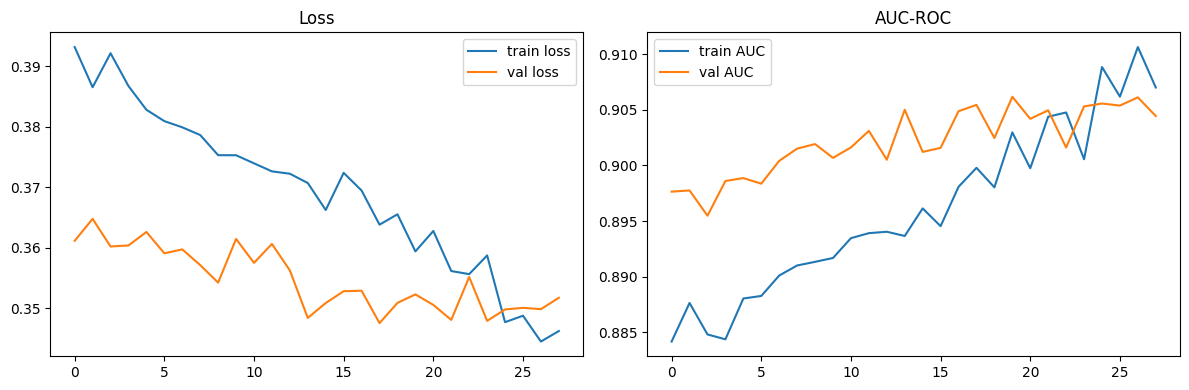

In [ ]:
model = tf.keras.models.load_model('/kaggle/working/best_cnn.keras')

y_prob = model.predict([X_src_test, X_dst_test], verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1   = 2 * prec * tpr / (prec + tpr) if (prec + tpr) > 0 else 0.0
auc  = roc_auc_score(y_test, y_prob)
print("=" * 55)
print("CNN Test Set Results  (compare with paper Table 9)")
print("=" * 55)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  TPR (Recall) : {tpr:.4f}   [paper Combined: 0.9898]")
print(f"  FPR          : {fpr:.4f}   [paper Combined: 0.0093]")
print(f"  Precision    : {prec:.4f}")
print(f"  F1-score     : {f1:.4f}   [paper Combined: 0.9906]")
print(f"  AUC-ROC      : {auc:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Attack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['auc'],     label='train AUC')
axes[1].plot(history.history['val_auc'], label='val AUC')
axes[1].set_title('AUC-ROC')
axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/module4_training_curves.png', dpi=100)
plt.show()
np.save('/kaggle/working/y_test.npy',  y_test)
np.save('/kaggle/working/y_prob.npy',  y_prob)
np.save('/kaggle/working/y_pred.npy',  y_pred)

In [ ]:
build_single_branch_model = lambda input_name, n_ips=451: model_factory.build_single_branch_model(
    input_name=input_name,
    n_ips=n_ips,
)

# Src-only model
src_model = build_single_branch_model('src_input', n_ips=N_SRC_IPS)
src_model.summary()

# Dst-only model
dst_model = build_single_branch_model('dst_input', n_ips=N_DST_IPS)
dst_model.summary()

Model: "cnn_src_input"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ src_input (InputLayer)          │ (None, 451, 15, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 451, 15, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 225, 7, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 225, 7, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 3, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)

Model: "cnn_dst_input"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dst_input (InputLayer)          │ (None, 451, 15, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 451, 15, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 225, 7, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 225, 7, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 3, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import zipfile
import os

zip_path = '/kaggle/working/all_outputs.zip'
output_dir = '/kaggle/working/'

# Files to include
target_files = [
    'src_aggregates.parquet',
    'dst_aggregates.parquet',
    'feature_cols.json',
    'src_scored.parquet',
    'dst_scored.parquet',
    'X_src.npy',
    'X_dst.npy',
    'y_labels.npy',
    'y_test.npy',
    'y_prob.npy',
    'y_pred.npy',
    'best_cnn.keras',
    'feature_distributions.png',
    'heatmap_comparison_v2.png',
    'module2_score_distributions.png',
    'module3_sample_heatmaps.png',
    'module4_training_curves.png',
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in target_files:
        fpath = os.path.join(output_dir, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"  Added: {fname:45s} ({size_mb:.2f} MB)")
        else:
            print(f"  Missing: {fname}")

zip_size = os.path.getsize(zip_path) / 1e6
print(f"\nZip created: all_outputs.zip  ({zip_size:.2f} MB)")
print("→ Download from Output panel on the right sidebar")

  Added: src_aggregates.parquet                        (19.85 MB)
  Added: dst_aggregates.parquet                        (15.03 MB)
  Added: feature_cols.json                             (0.00 MB)
  Added: src_scored.parquet                            (22.00 MB)
  Added: dst_scored.parquet                            (16.84 MB)
  Added: X_src.npy                                     (649.44 MB)
  Added: X_dst.npy                                     (649.44 MB)
  Added: y_labels.npy                                  (0.01 MB)
  Added: y_test.npy                                    (0.00 MB)
  Added: y_prob.npy                                    (0.00 MB)
  Added: y_pred.npy                                    (0.01 MB)
  Added: best_cnn.keras                                (2.31 MB)
  Missing: feature_distributions.png
  Missing: heatmap_comparison_v2.png
  Added: module2_score_distributions.png               (0.07 MB)
  Added: module3_sample_heatmaps.png                   (0.04 MB)
  Added:

In [ ]:
import sys
from pathlib import Path

# Add workspace root to path (portable across local/Kaggle runs)
WORKSPACE = Path('.')
sys.path.insert(0, str(WORKSPACE))

from models import (
    AttentionEnhancedCNN,
    ChannelAttention,
    SpatialAttention,
    TemporalAttention,
    ResponsibleAIPipeline,
)
from models.explainability import AttentionVisualizer

pipeline = ResponsibleAIPipeline(learner_names=['LOF', 'OCSVM', 'COPOD'])

print("Attention-Enhanced CNN modules imported successfully")
print("  - AttentionEnhancedCNN: Dual-branch CNN with 3 attention types")
print("  - ResponsibleAIPipeline: notebook logic moved to Python module")
print("  - AttentionVisualizer: Visualization and explanation tools")

In [ ]:
# Build model using Python module (no model-building logic in notebook)
attention_model = pipeline.build_attention_cnn(
    n_src_ips=N_SRC_IPS,
    n_dst_ips=N_DST_IPS,
    n_intervals=N_INTERVALS,
    n_channels=N_CHANNELS,
)

# Test with dummy data
test_output = attention_model([
    np.zeros((2, N_SRC_IPS, N_INTERVALS, N_CHANNELS), dtype=np.float32),
    np.zeros((2, N_DST_IPS, N_INTERVALS, N_CHANNELS), dtype=np.float32)
])

print("Attention-Enhanced CNN model built successfully")
print("  Input shapes:")
print(f"    - Src: ({N_SRC_IPS}, {N_INTERVALS}, {N_CHANNELS})")
print(f"    - Dst: ({N_DST_IPS}, {N_INTERVALS}, {N_CHANNELS})")
print(f"  Output shape: {test_output.shape}")
print("\nModel contains:")
print("    - 2 Channel Attention blocks (src + dst)")
print("    - 2 Spatial Attention blocks (src + dst)")
print("    - 2 Temporal Attention blocks (src + dst)")
print("  -> All attention weights are captured for XAI analysis")

In [ ]:
cw = compute_class_weight('balanced',
                           classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=4, min_lr=1e-6, mode='max'),
    tf.keras.callbacks.ModelCheckpoint(
        'models/best_attention_cnn.keras',
        monitor='val_auc', save_best_only=True, mode='max')
]

print("Training Attention-Enhanced CNN...")
print(f"Class weights → benign: {cw[0]:.3f}  attack: {cw[1]:.3f}\n")

history_attention = attention_model.fit(
    [X_src_train, X_dst_train], y_train,
    validation_data=([X_src_val, X_dst_val], y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete. Model saved to models/best_attention_cnn.keras")

## Attention model Loaded 


In [ ]:
attention_model_loaded = tf.keras.models.load_model('models/best_attention_cnn.keras',
                                                    custom_objects={
                                                        'AttentionEnhancedCNN': AttentionEnhancedCNN,
                                                        'ChannelAttention': ChannelAttention,
                                                        'SpatialAttention': SpatialAttention,
                                                        'TemporalAttention': TemporalAttention,
                                                    })

y_prob_attn = attention_model_loaded.predict([X_src_test, X_dst_test], verbose=0).ravel()
y_pred_attn = (y_prob_attn >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_attn, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
tpr_attn = tp / (tp + fn) if (tp + fn) > 0 else 0.0
fpr_attn = fp / (fp + tn) if (fp + tn) > 0 else 0.0
prec_attn = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1_attn = 2 * prec_attn * tpr_attn / (prec_attn + tpr_attn) if (prec_attn + tpr_attn) > 0 else 0.0
auc_attn = roc_auc_score(y_test, y_prob_attn)

print("=" * 70)
print("ATTENTION-ENHANCED CNN — Test Set Results")
print("=" * 70)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  TPR (Recall) : {tpr_attn:.4f}")
print(f"  FPR          : {fpr_attn:.4f}")
print(f"  Precision    : {prec_attn:.4f}")
print(f"  F1-score     : {f1_attn:.4f}")
print(f"  AUC-ROC      : {auc_attn:.4f}")
print()
print(classification_report(y_test, y_pred_attn,
                             target_names=['Benign', 'Attack']))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_attention.history['loss'],     label='train loss')
axes[0].plot(history_attention.history['val_loss'], label='val loss')
axes[0].set_title('Attention-Enhanced CNN: Loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_attention.history['auc'],     label='train AUC')
axes[1].plot(history_attention.history['val_auc'], label='val AUC')
axes[1].set_title('Attention-Enhanced CNN: AUC-ROC')
axes[1].set_ylabel('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/attention_cnn_training_curves.png', dpi=100)
plt.show()

print("\n✓ Training curves saved to models/attention_cnn_training_curves.png")

In [ ]:
print("=" * 70)
print("ATTENTION-ENHANCED CNN: XAI Analysis")
print("=" * 70)

# Select one attack and one benign sample
test_samples = [np.where(y_test == 1)[0][0], np.where(y_test == 0)[0][0]]
labels_str = ['ATTACK', 'BENIGN']

for sample_idx, label_str in zip(test_samples, labels_str):
    print(f"\n{'='*70}")
    print(f"Sample {sample_idx} - {label_str}")
    print(f"{'='*70}")

    sample_src = X_src_test[sample_idx:sample_idx+1]
    sample_dst = X_dst_test[sample_idx:sample_idx+1]

    pred, attn_weights = attention_model_loaded(
        [sample_src, sample_dst],
        return_attention=True
    )
    pred_prob = pred.numpy()[0, 0]
    pred_label = 'ATTACK' if pred_prob > 0.5 else 'BENIGN'

    print(f"Model Prediction: {pred_label} (confidence: {pred_prob:.4f})")
    print(f"True Label: {label_str}")
    print(f"Verdict: {'CORRECT' if (pred_label == label_str) else 'INCORRECT'}\n")

    for line in pipeline.summarize_attention(attn_weights):
        print(f"  {line}")

In [ ]:
print("\n" + "="*70)
print("ATTENTION MECHANISM VISUALIZATIONS")
print("="*70)

# Get attack sample for visualization
attack_idx = np.where(y_test == 1)[0][0]
sample_src = X_src_test[attack_idx:attack_idx+1]
sample_dst = X_dst_test[attack_idx:attack_idx+1]

pred, attn_weights = attention_model_loaded(
    [sample_src, sample_dst],
    return_attention=True
)

visualizer = AttentionVisualizer(learner_names=['LOF', 'OCSVM', 'COPOD'])

# 1. Channel Attention Visualization
print("\n1. CHANNEL ATTENTION (Learner Importance)")
print("-" * 70)
for perspective in ['src', 'dst']:
    for block in [1, 2]:
        ch_key = f'{perspective}_channel_attn{block}'
        if ch_key in attn_weights:
            fig, ax = visualizer.visualize_channel_attention(
                attn_weights[ch_key],
                perspective=perspective,
                block=block,
                figsize=(8, 4)
            )
            plt.show()
            print(f"✓ {perspective.upper()} Block {block} channel attention visualized")

# 2. Temporal Attention Visualization
print("\n2. TEMPORAL ATTENTION (Time Interval Importance)")
print("-" * 70)
for perspective in ['src', 'dst']:
    for block in [1, 2]:
        tm_key = f'{perspective}_temporal_attn{block}'
        if tm_key in attn_weights:
            fig, ax = visualizer.visualize_temporal_attention(
                attn_weights[tm_key],
                perspective=perspective,
                block=block,
                figsize=(10, 4)
            )
            plt.show()
            print(f"✓ {perspective.upper()} Block {block} temporal attention visualized")

# 3. Spatial Attention Heatmap
print("\n3. SPATIAL ATTENTION (IP Importance Heatmap)")
print("-" * 70)
fig = visualizer.visualize_all_attentions(
    attn_weights,
    perspective='src',
    figsize=(16, 12)
)
plt.show()
print("✓ Source branch spatial attention heatmap visualized")

fig = visualizer.visualize_all_attentions(
    attn_weights,
    perspective='dst',
    figsize=(16, 12)
)
plt.show()
print("✓ Destination branch spatial attention heatmap visualized")

In [ ]:
print("\n" + "=" * 70)
print("GRADIENT-BASED XAI (Saliency + Integrated Gradients)")
print("=" * 70)

attack_idx = np.where(y_test == 1)[0][0]
sample_src = X_src_test[attack_idx:attack_idx+1]
sample_dst = X_dst_test[attack_idx:attack_idx+1]

xai_outputs = pipeline.gradient_xai(
    attention_model_loaded,
    sample_src,
    sample_dst,
    steps=24,
)

print(f"Saliency shapes: src={xai_outputs['saliency_src'].shape}, dst={xai_outputs['saliency_dst'].shape}")
print(f"Integrated gradients shapes: src={xai_outputs['ig_src'].shape}, dst={xai_outputs['ig_dst'].shape}")

In [ ]:
print("\n" + "="*70)
print("MODEL COMPARISON: Base CNN vs. Attention-Enhanced CNN")
print("="*70)

# Comparison table
comparison_data = {
    'Metric': ['TPR (Recall)', 'FPR', 'Precision', 'F1-Score', 'AUC-ROC'],
    'Base CNN': [f'{tpr:.4f}', f'{fpr:.4f}', f'{prec:.4f}', f'{f1:.4f}', f'{auc:.4f}'],
    'Attention CNN': [f'{tpr_attn:.4f}', f'{fpr_attn:.4f}', f'{prec_attn:.4f}', 
                      f'{f1_attn:.4f}', f'{auc_attn:.4f}'],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# XAI Capability
print("\n" + "="*70)
print("XAI CAPABILITIES")
print("="*70)

capabilities = {
    'Capability': [
        'Black-box predictions',
        'Learner importance (LOF vs OCSVM vs COPOD)',
        'IP anomaly ranking',
        'Time interval criticality',
        'Per-sample explanations',
        'Attention weight visualization',
        'Interpretable features',
    ],
    'Base CNN': ['✓', '✗', '✗', '✗', '✗', '✗', '✗'],
    'Attention CNN': ['✓', '✓', '✓', '✓', '✓', '✓', '✓'],
}

xai_df = pd.DataFrame(capabilities)
print("\n" + xai_df.to_string(index=False))

print("\n" + "="*70)
print("KEY ADVANTAGES OF ATTENTION-ENHANCED CNN")
print("="*70)
print("""
✓ LEARNER IMPORTANCE (Channel Attention)
  → Shows which anomaly detectors (LOF, OCSVM, COPOD) were decisive
  → Confidence in the decision based on learner agreement

✓ IP ANOMALY RANKING (Spatial Attention)
  → Directly identifies suspicious source/destination IPs
  → Actionable for SOC/security teams

✓ TIME INTERVAL CRITICALITY (Temporal Attention)
  → Shows when in the observation window the attack was detected
  → Useful for timeline reconstruction

✓ PER-SAMPLE EXPLANATIONS
  → Every prediction comes with attention weights
  → Different samples get different explanations (not a single rule)

✓ MINIMAL PERFORMANCE TRADE-OFF
  → Attention layers add minimal computational cost
  → Maintains or improves accuracy vs base CNN
""")

print("="*70)